In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression, SGDRegressor

from sklearn.preprocessing import PolynomialFeatures, StandardScaler

from sklearn.metrics import r2_score

from sklearn.pipeline import Pipeline

In [3]:
x = 6 * np.random.rand(200,1) - 3
y = 0.8 * x **2 + 0.9 * x + 2 + np.random.randn(200,1)

# y = 0.8 x^2 + 0.9x + 2

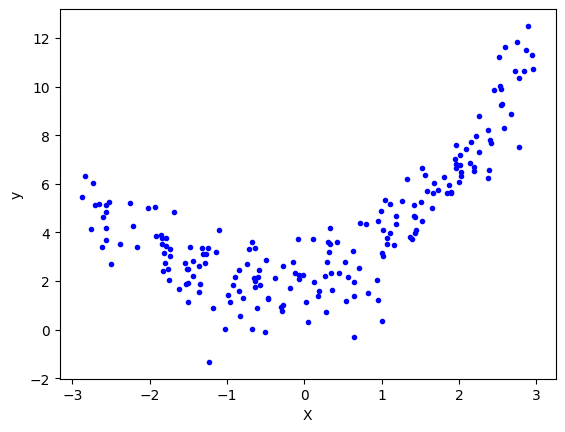

In [4]:
plt.plot(x,y,'b.')
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [5]:
# train,test, split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2, random_state = 2)

In [6]:
# applying linear regression
lr = LinearRegression()

In [7]:
lr.fit(x_train,y_train)

LinearRegression()

In [8]:
y_pred = lr.predict(x_test)
r2_score(y_test,y_pred)

0.34210176469891096

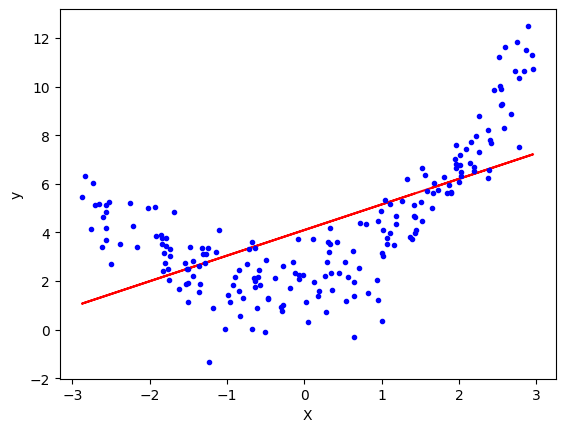

In [9]:
plt.plot(x_train,lr.predict(x_train),color='r')
plt.plot(x,y,"b.")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [10]:
# applying polynomial linear regression
# degree 2
poly = PolynomialFeatures(degree=2,include_bias=True)

x_train_trans = poly.fit_transform(x_train)
x_test_trans = poly.transform(x_test)

In [11]:
print(x_train[0])
print(x_train_trans[0])

[1.41544599]
[1.         1.41544599 2.00348734]


In [12]:
# include_bias parameter

lr = LinearRegression()
lr.fit(x_train_trans,y_train)

LinearRegression()

In [13]:
y_pred = lr.predict(x_test_trans)
r2_score(y_test,y_pred)

0.7771049187938337

In [14]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.88564711 0.79066835]]
[1.89168272]


In [15]:
x_new = np.linspace(-3,3,200).reshape(200,1)
x_new_poly = poly.transform(x_new)
y_new = lr.predict(x_new_poly)

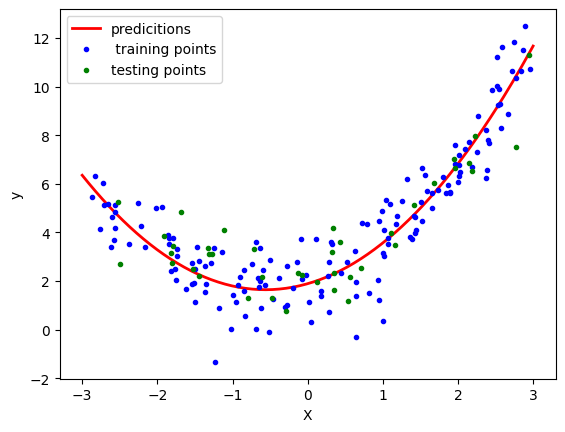

In [16]:
plt.plot(x_new,y_new,"r-",linewidth=2,label="predicitions")
plt.plot(x_train,y_train,"b.",label=' training points')
plt.plot(x_test,y_test,"g.",label="testing points")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [17]:
def polynomial_regression(degree):
  x_new = np.linspace(-3,3,100).reshape(100,1)
  x_new_poly = poly.transform(x_new)

  polybig_features = PolynomialFeatures(degree=degree,include_bias=False)
  std_scaler = StandardScaler()
  lin_reg = LinearRegression()
  polynomial_regression = Pipeline([
      ("poly_features",polybig_features),
      ("std_Scaler",std_scaler),
      ("lin_reg",lin_reg),
  ])

  polynomial_regression.fit(x,y)
  y_newbig = polynomial_regression.predict(x_new)
  plt.plot(x_new,y_newbig,'r',label='Degree' + str(degree),linewidth=2)

  plt.plot(x_train, y_train,"b.",linewidth=3)
  plt.plot(x_test,y_test,"g.",linewidth=3)
  plt.legend(loc="upper left")
  plt.xlabel("X")
  plt.ylabel("y")
  plt.axis([-3,3,0,10])
  plt.show()

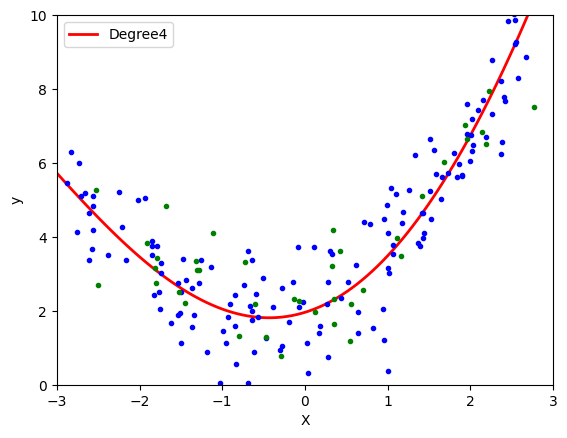

In [18]:
polynomial_regression(4)

In [19]:
poly.powers_

array([[0],
       [1],
       [2]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


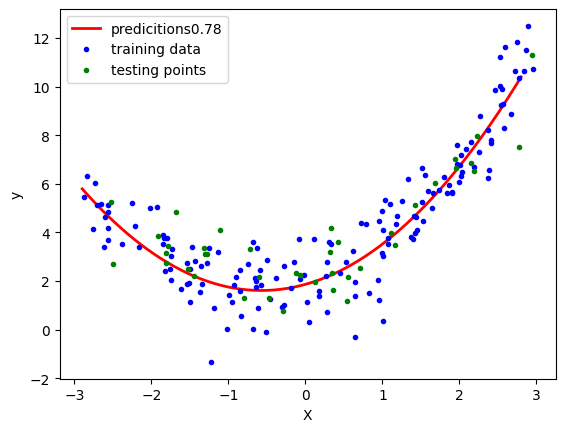

In [20]:
# applying gradient descent

poly = PolynomialFeatures(degree=2)

x_train_trans = poly.fit_transform(x_train)
x_test_trans = poly.transform(x_test)

sgd = SGDRegressor(max_iter = 100)
sgd.fit(x_train_trans,y_train)

x_new = np.linspace(-2.9,2.8,200).reshape(200,1)
x_new_poly = poly.transform(x_new)
y_new = sgd.predict(x_new_poly)

y_pred = sgd.predict(x_test_trans)

plt.plot(x_new,y_new,"r-",linewidth=2,label="predicitions" + str(round(r2_score(y_test,y_pred),2)))
plt.plot(x_train,y_train,"b.",label="training data")
plt.plot(x_test,y_test,"g.",label="testing points")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [22]:
# 3D polynomial regression
x = 7 * np.random.rand(100,1) - 2.8
y = 7 * np.random.rand(100,1) - 2.8

z = x **2 + y **2 + 0.2 *x + 0.2 *y + 0.1*x*y + 2 + np.random.randn(100,1)

In [23]:
import plotly.express as px
df = px.data.iris()
fig = px.scatter_3d(df,x=x.ravel(),y=y.ravel(),z = z.ravel())
fig.show()

In [25]:
lr = LinearRegression()
lr.fit(np.array([x,y]).reshape(100,2),z)

x_input = np.linspace(x.min(),x.max(),10)
y_input = np.linspace(y.min(),y.max(),10)
xGrid, yGrid = np.meshgrid(x_input,y_input)

final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T

z_final = lr.predict(final).reshape(10,10)

In [26]:
import plotly.graph_objects as go

fig = px.scatter_3d(df,x=x.ravel(),y=y.ravel(),z=z.ravel())

fig.add_trace(go.Surface(x=x_input, y=y_input, z = z_final))

fig.show()

In [27]:
x_multi = np.array([x,y]).reshape(100,2)
x_multi.shape

(100, 2)

In [29]:
poly = PolynomialFeatures(degree=30)
x_multi_trans = poly.fit_transform(x_multi)

In [30]:
x_multi_trans.shape

(100, 496)

In [31]:
lr = LinearRegression()
lr.fit(x_multi_trans,z)

LinearRegression()

In [32]:
x_test_multi = poly.transform(final)

In [33]:
z_final = lr.predict(x_multi_trans).reshape(10,10)

In [34]:
fig = px.scatter_3d(x=x.ravel(),y = y.ravel(),z=z.ravel())

fig.add_trace(go.Surface(x=x_input,y=y_input,z = z_final))

fig.update_layout(scene = dict(zaxis = dict(range=[0,35])))

fig.show()